# $\beta$-Regularity for Top Forms in 2D

### How degrading the smoothness of the velocity field affects computed spectra, pseudospectra, and spectral pollution

---

This is the $k = n = 2$ companion to `beta_regularity_1form.ipynb`. It asks the same
questions — what happens to computed spectra when $\beta$ leaves $W^{1,\infty}$, and then
$L^\infty$ — and adds one that only top forms make available.

At $k = n$ a **deliberately spurious element** is available as a control: the
Boffi–Brezzi–Gastaldi pair $\Sigma_h = [P_1]^2$, $V_h = \operatorname{div}\Sigma_h$ on a
criss-cross mesh, which is conforming and inf–sup stable and nevertheless produces a
complete shadow spectrum at $3\varepsilon(m^2+n^2)$ in the diffusive limit. Running it
alongside the structure-preserving formulations turns every experiment here into a paired
comparison: whatever the rough field does to a sound discretisation can be read against
what it does to a broken one.

**Contents**

1. [The problem and the formulations](#1)
2. [The velocity fields](#2)
3. [Fields in $L^\infty\setminus W^{1,\infty}$](#3)
4. [Fields in $L^p$](#4)
5. [Summary](#5)

<a id="0"></a>
## 0. Setup

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Optional

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from firedrake import *
from firedrake.function import PointEvaluator
from firedrake.pyplot import triplot, tripcolor

from petsc4py import PETSc
from slepc4py import SLEPc

import spectral_common as sc
import pseudospectra_partial_schur as ps
from spectral_common import (crisscross_mesh, solve_pencil, condition_estimates,
                             to_scipy, to_petsc, rates, assign, agreeing_digits,
                             spread, L_DOMAIN, KAPPA_LOG)

import logging as stdlogging
stdlogging.getLogger("firedrake").setLevel(stdlogging.ERROR)
stdlogging.getLogger("tsfc").setLevel(stdlogging.ERROR)

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "cm",
    "font.size": 11, "axes.titlesize": 11, "axes.labelsize": 11,
    "figure.dpi": 110, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "axes.linewidth": 0.6,
})
PS_RC = {
    "font.family": "serif", "mathtext.fontset": "cm",
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.linewidth": 0.6, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
}


def show(df, caption=None, **kw):
    """`sc.fmt_table` wired to this notebook's display function."""
    return sc.fmt_table(df, caption=caption,
                        display_fn=lambda c: display(Markdown(f"**{c}**")), **kw)


print(f"PETSc scalars: {PETSc.ScalarType.__name__}")

PETSc scalars: float64


<a id="1"></a>
## 1. The problem and the formulations

For top forms in 2D the unknown is a **scalar**: $\mathrm{d}^n u = 0$ holds identically, so
the closedness constraint is vacuous and the Lagrange multiplier disappears. In the rotated
proxies $\iota^n_\beta u \leftrightarrow u\beta$, $\delta^n \leftrightarrow -\nabla$ and
$\mathrm{d}^{n-1} \leftrightarrow \operatorname{div}$, and the half-Hodge problem is the
scalar advection–diffusion eigenvalue problem

$$
-\varepsilon\,\Delta u \;+\; \nabla\!\cdot(\beta u) \;=\; \lambda\,u \quad\text{in }\Omega,
\qquad u = 0 \ \text{ on }\partial\Omega, \qquad \varepsilon = R_m^{-1},
$$

the Dirichlet condition being the FEEC one, $\operatorname{Tr}(\star u) = 0$.

**Three families of discretisation are run.**

*Primal.* $A(\mathcal{P}_r)$: the direct reduction, $\mathcal{P}_r \cap H^1_0$, with the
boundary condition essential.

*Mixed, in the total flux.* With
$\sigma := \varepsilon\delta^n u + \iota^n_\beta u \leftrightarrow u\beta - \varepsilon\nabla u$,

$$
\begin{cases}
(\varepsilon^{-1}\sigma, \tau) - (\varepsilon^{-1}\iota^n_\beta u, \tau) - (u, \operatorname{div}\tau) = 0 & \forall\tau,\\[2pt]
(\operatorname{div}\sigma,\ v) + \nu(u,v) = (\lambda+\nu)(u,v) & \forall v,
\end{cases}
$$

with the Dirichlet condition now **natural**. Two conforming pairs preserve the structure —
$\mathrm{RT}_r\times\mathrm{DG}_{r-1}$ and $\mathrm{BDM}_r\times\mathrm{DG}_{r-1}$ — and are
run both unshifted ($B$, $\nu = 0$) and with the shift $\nu$ that the well-posedness
argument requires ($\sigma$).

*The trap.* $\sigma(P_1\text{–div}P_1)$: the same bilinear form on
$\Sigma_h = [P_1]^2 \subset H(\operatorname{div})$ with $V_h = \operatorname{div}\Sigma_h$,
on a criss-cross mesh. Conforming, inf–sup stable, a subspace of
$\mathrm{BDM}_1\times\mathrm{DG}_0$ — and it pollutes. On the criss-cross grid the
divergence is not surjective onto $\mathrm{DG}_0$; its cokernel is the checkerboard mode,
one per macro-square, and quotienting it out leaves a space carrying a second complete copy
of the spectrum. This element is lowest-order by construction, so it appears in the
$h$-studies but not the $p$-studies.

In [2]:
def crisscross_blocks(mesh, N, L=L_DOMAIN):
    """Group the 4N^2 cells into N^2 macro-squares, by centroid.

    Nothing depends on Firedrake's internal cell ordering: within a macro-square
    the four sub-triangle centroids sit at the centre plus (+-h/3, 0) and
    (0, +-h/3), so |dy| > |dx| picks out the north/south pair.
    """
    W = VectorFunctionSpace(mesh, "DG", 0)
    centroid = Function(W).interpolate(SpatialCoordinate(mesh)).dat.data_ro
    h = L / N
    idx = np.clip(np.floor(centroid / h).astype(int), 0, N - 1)
    offset = centroid - (idx + 0.5) * h
    north_south = np.abs(offset[:, 1]) > np.abs(offset[:, 0])
    blocks = np.argsort(idx[:, 0] * N + idx[:, 1], kind="stable").reshape(N * N, 4)
    return blocks, north_south


def checkerboard_complement(mesh, N, L=L_DOMAIN):
    r"""Orthonormal basis of $V_h = \operatorname{div}[P_1]^2$.

    The cokernel of the divergence is spanned, one vector per macro-square, by the
    checkerboard $+1$ on north/south and $-1$ on east/west; these have disjoint
    supports and are therefore mutually orthogonal, so a basis of the complement
    can be written down three vectors at a time.
    """
    blocks, north_south = crisscross_blocks(mesh, N, L)
    ncell, q = 4 * N * N, 1 / np.sqrt(2)
    rows, cols, vals = [], [], []
    for k, blk in enumerate(blocks):
        ns, ew = blk[north_south[blk]], blk[~north_south[blk]]
        for j, (cells, v) in enumerate([(tuple(ns), (q, -q)), (tuple(ew), (q, -q)),
                                        (tuple(blk), (0.5,) * 4)]):
            rows += list(cells); cols += [3 * k + j] * len(cells); vals += list(v)
    return sp.csr_matrix((vals, (rows, cols)), shape=(ncell, 3 * N * N))


def build_pencil(form, mesh, N, r=1, beta=None, eps=Constant(1.0), nu=0.0):
    r"""Assemble $(A, M)$ for one formulation.  $M$ is singular in every case."""
    if form == "A(CG)":
        V = FunctionSpace(mesh, "CG", r)
        u, v = TrialFunction(V), TestFunction(V)
        a = eps * inner(grad(u), grad(v)) * dx
        if beta is not None:
            a -= inner(u * beta, grad(v)) * dx      # iota^n_beta u  <->  u * beta
        if nu:
            a += Constant(nu) * inner(u, v) * dx
        bcs = [DirichletBC(V, Constant(0.0), "on_boundary")]
        return (assemble(a, bcs=bcs).petscmat,
                assemble(inner(u, v) * dx, bcs=bcs, weight=0.0).petscmat, V)

    if form in ("B(RT)", "B(BDM)", "s(RT)", "s(BDM)"):
        family = "RT" if form.endswith("(RT)") else "BDM"
        W = FunctionSpace(mesh, family, r) * FunctionSpace(mesh, "DG", r - 1)
        (s_, u) = TrialFunctions(W)
        (t_, v) = TestFunctions(W)
        a = ((1 / eps) * inner(s_, t_) * dx
             - inner(u, div(t_)) * dx
             + inner(div(s_), v) * dx)
        if beta is not None:
            a -= (1 / eps) * inner(u * beta, t_) * dx
        if nu:
            a += Constant(nu) * inner(u, v) * dx
        # No boundary condition anywhere: u = 0 on the boundary is natural here.
        return assemble(a).petscmat, assemble(inner(u, v) * dx).petscmat, W

    # s(P1-divP1): assembled blockwise, then the DG0 side restricted to div(Sigma_h).
    S = VectorFunctionSpace(mesh, "CG", 1)
    Q = FunctionSpace(mesh, "DG", 0)
    s_, t_ = TrialFunction(S), TestFunction(S)
    u, v = TrialFunction(Q), TestFunction(Q)
    A_ss = to_scipy(assemble((1 / eps) * inner(s_, t_) * dx).petscmat)
    form_su = -inner(u, div(t_)) * dx
    if beta is not None:
        form_su = form_su - (1 / eps) * inner(u * beta, t_) * dx
    A_su = to_scipy(assemble(form_su).petscmat)
    A_us = to_scipy(assemble(inner(div(s_), v) * dx).petscmat)
    M_uu = to_scipy(assemble(inner(u, v) * dx).petscmat)

    Z = checkerboard_complement(mesh, N)
    A_su, A_us = A_su @ Z, Z.T @ A_us
    M_uu = Z.T @ M_uu @ Z
    A = sp.bmat([[A_ss, A_su], [A_us, sp.csr_matrix(nu * M_uu)]], format="csr")
    M = sp.bmat([[sp.csr_matrix(A_ss.shape), None],
                 [None, sp.csr_matrix(M_uu)]], format="csr")
    return to_petsc(A), to_petsc(M), (S, Q)


FEEC = ["A(CG)", "B(RT)", "B(BDM)"]
ALL_FORMS = FEEC + ["s(RT)", "s(BDM)", "s(P1-divP1)"]
H_FORMS = FEEC + ["s(P1-divP1)"]        # everything that exists at lowest order
TEX = {"A(CG)": r"$A(\mathcal{P}_r)$", "B(RT)": r"$B(\mathrm{RT}_r)$",
       "B(BDM)": r"$B(\mathrm{BDM}_r)$", "s(RT)": r"$\sigma(\mathrm{RT}_r)$",
       "s(BDM)": r"$\sigma(\mathrm{BDM}_r)$",
       "s(P1-divP1)": r"$\sigma(P_1\text{–div}P_1)$"}
TAG = {"A(CG)": "ACG", "B(RT)": "BRT", "B(BDM)": "BBDM",
       "s(RT)": "sRT", "s(BDM)": "sBDM", "s(P1-divP1)": "sP1"}


def nu_for(form, beta_sup, Rm):
    r"""The shift of the well-posedness argument, $\nu \ge 2\|\beta\|_\infty^2/\varepsilon + 2$.

    Only the two $\sigma$ rows carry it; everything else runs unshifted so that the
    returned eigenvalues are $\lambda$ itself.  For an unbounded field the bound is
    vacuous, and the *effective* magnitude on the mesh is used instead -- which is
    exactly the quantity the discretisation sees.
    """
    if not form.startswith("s(") or form == "s(P1-divP1)":
        return 0.0
    return 2.0 * beta_sup ** 2 * Rm + 2.0


def solve_form(form, mesh, N, r=1, beta=None, Rm=1.0, tau=None, nev=30,
               n_eigs=None, beta_sup=1.0, **meta):
    r"""Assemble and solve one configuration; ``tau`` defaults to $1.9\varepsilon$."""
    nu = nu_for(form, beta_sup, Rm)
    A, M, W = build_pencil(form, mesh, N, r, beta=beta, eps=Constant(1.0 / Rm), nu=nu)
    tau = (1.9 / Rm) if tau is None else tau
    res = solve_pencil(A, M, tau + nu, nev=nev, n_eigs=n_eigs, space=W,
                       form=form, r=r, Rm=Rm, **meta)
    if nu:
        # Undo the shift so every row of every table is directly comparable.
        res.values = res.values - nu
    return res


def exact_spectrum(n, Rm=1.0, kmax=40):
    r"""$\varepsilon(m^2+n^2)$, $m,n\ge1$: the Dirichlet Laplacian on $(0,\pi)^2$."""
    vals = sorted(m * m + k * k for m in range(1, kmax) for k in range(1, kmax))
    return np.array(vals[:n], dtype=float) / Rm

<a id="2"></a>
## 2. The velocity fields

The same four fields as the $1$-form study, so the two can be read against one another.

| Tag | $\beta$ | Regularity | $\nabla\!\cdot\beta = 0$ |
|:--|:--|:--|:--:|
| `b6` | $(\operatorname{sign}(x-\tfrac{\pi}{2}),\ 0)$ | $L^\infty\setminus W^{1,\infty}$ | no |
| `b7` | $(\operatorname{sign}(y-\tfrac{\pi}{2}),\ 0)$ | $L^\infty\setminus W^{1,\infty}$ | yes |
| `b8` | $(\operatorname{sign}(x-\tfrac{\pi}{2}),\ \operatorname{sign}(x-\tfrac{\pi}{2}))$ | $L^\infty\setminus W^{1,\infty}$ | no |
| `b9`$(\alpha)$ | $\bigl(-\hat y/r_c^{\alpha},\ \hat x/r_c^{\alpha}\bigr)$ | $L^p$, $1\le p<\tfrac{2}{\alpha-1}$ | yes |

Note that at $k=n$ the advective term is $\nabla\!\cdot(\beta u)$ and **not** $\beta\cdot\nabla u$;
the two differ precisely when $\beta$ is not solenoidal, so `b6` and `b8` exercise a part of
the operator that the $1$-form problem does not.

In [3]:
@dataclass(frozen=True)
class Field:
    key: str
    tex: str
    regularity: str
    solenoidal: bool
    sup: Optional[float]
    _build: Callable

    def __call__(self, mesh, L=L_DOMAIN, **kw):
        return self._build(mesh, L, **kw)


def _b6(mesh, L):
    x, y = SpatialCoordinate(mesh)
    return as_vector([conditional(gt(x, Constant(L / 2)), 1.0, -1.0), Constant(0.0)])


def _b7(mesh, L):
    x, y = SpatialCoordinate(mesh)
    return as_vector([conditional(gt(y, Constant(L / 2)), 1.0, -1.0), Constant(0.0)])


def _b8(mesh, L):
    x, y = SpatialCoordinate(mesh)
    s = conditional(gt(x, Constant(L / 2)), 1.0, -1.0)
    return as_vector([s, s])


def _b9(mesh, L, alpha=1.5, delta=1e-12):
    """The L^p vortex; `delta` floors r_c so the expression stays finite if a
    quadrature point lands on the centre."""
    x, y = SpatialCoordinate(mesh)
    xc = yc = Constant(L / 2)
    r = sqrt((x - xc) ** 2 + (y - yc) ** 2 + Constant(delta))
    return as_vector([-(y - yc) / r ** alpha, (x - xc) / r ** alpha])


FIELDS = {
    "b6": Field("b6", r"$(\mathrm{sign}(x-\frac{\pi}{2}),\,0)$",
                r"$L^\infty\setminus W^{1,\infty}$", False, 1.0, _b6),
    "b7": Field("b7", r"$(\mathrm{sign}(y-\frac{\pi}{2}),\,0)$",
                r"$L^\infty\setminus W^{1,\infty}$", True, 1.0, _b7),
    "b8": Field("b8", r"$(\mathrm{sign}(x-\frac{\pi}{2}),\,\mathrm{sign}(x-\frac{\pi}{2}))$",
                r"$L^\infty\setminus W^{1,\infty}$", False, np.sqrt(2.0), _b8),
    "b9": Field("b9", r"$(-\hat y/r^{\alpha},\ \hat x/r^{\alpha})$", r"$L^p$",
                True, None, _b9),
}
ROUGH = ["b6", "b7", "b8"]


def effective_sup(mesh, beta):
    """The largest cell-average of |beta|: what the discretisation actually sees."""
    mag = Function(FunctionSpace(mesh, "DG", 0)).interpolate(sqrt(dot(beta, beta)))
    return float(np.abs(mag.dat.data_ro).max())

<a id="3"></a>
## 3. Fields in $L^\infty\setminus W^{1,\infty}$

### 3.1 Cross-validation of the reference values

Reference values are established on a refined mesh at high polynomial degree and checked by
cross-validation across the **structure-preserving** formulations only. The
$\sigma(P_1\text{–div}P_1)$ row is deliberately excluded from the reference: it is the
control, and Section 3.5 asks what it does.

The two $\sigma$ rows carry the shift $\nu \ge 2\|\beta\|^2_\infty/\varepsilon + 2$ that the
well-posedness argument requires and hand back $\tilde\lambda - \nu$. Whether that shift is
still spectrally inert when $\beta$ is only $L^\infty$ is itself something to check, and the
table checks it.

In [4]:
N_REF, R_REF, NEV_REF = 24, 3, 25

mesh_ref = crisscross_mesh(N_REF)
ref_runs, REFERENCE = {}, {}
for key in ROUGH:
    beta_ref = FIELDS[key](mesh_ref)
    for form in FEEC + ["s(RT)", "s(BDM)"]:
        ref_runs[(key, form)] = solve_form(form, mesh_ref, N_REF, R_REF,
                                           beta=beta_ref, nev=NEV_REF, n_eigs=5,
                                           beta_sup=FIELDS[key].sup, field=key)
    stack = np.array([ref_runs[(key, f)].values[:5] for f in FEEC])
    REFERENCE[key] = stack.mean(axis=0)

rows = []
for key in ROUGH:
    stack = np.array([ref_runs[(key, f)].values[:5] for f in FEEC])
    sprd = spread(stack)
    for j in range(5):
        rows.append(dict(field=key, j=j + 1,
                         **{TEX["A(CG)"]: stack[0, j], TEX["B(RT)"]: stack[1, j],
                            TEX["B(BDM)"]: stack[2, j], "spread": sprd[j],
                            "digits": agreeing_digits(stack[:, j])}))
show(pd.DataFrame(rows).set_index(["field", "j"]), default="{:.9f}",
     rules=[("spread", "{:.2e}"), ("digits", "{:.0f}")],
     caption=rf"Cross-validation of the first five eigenvalues over the FEEC "
             rf"formulations, $R_m = 1$, $N = {N_REF}$, $r = {R_REF}$")

**Cross-validation of the first five eigenvalues over the FEEC formulations, $R_m = 1$, $N = 24$, $r = 3$**

$A(\mathcal{P}_r)$ $B(\mathrm{RT}_r)$ $B(\mathrm{BDM}_r)$    spread  \
field j                                                                       
b6    1        2.796048353        2.796048353         2.796048353  7.29e-11   
      2        5.249999999        5.249999999         5.250000000  6.69e-10   
      3        5.796048357        5.796048354         5.796048355  2.52e-09   
      4        8.250000008        8.250000000         8.250000007  8.24e-09   
      5       10.796048440       10.796048388        10.796048405  5.24e-08   
b7    1        2.098061108        2.098061183         2.098061143  7.51e-08   
      2   5.14234+0.72757i   5.14234+0.72757i    5.14234+0.72757i  1.50e-07   
      3   5.14234-0.72757i   5.14234-0.72757i    5.14234-0.72757i  1.50e-07   
      4   9.16222+0.75768i   9.16222+0.75768i    9.16222+0.75768i  6.03e-07   
      5   9.16222-0.75768i   9.16222-0.75768i    9.16222-0.75768i  6.03e-07   
b8    1        2.910646821        2.910646878         2.910646848  5.67e-08   
      2   5.67745+0.65922i   5.67745+0.65922i    5.67745+0.65922i  1.29e-07   
      3   5.67745-0.65922i   5.67745-0.65922i    5.67745-0.65922i  1.29e-07   
      4        9.319566973        9.319566226         9.319566645  7.46e-07   
      5       10.079221827       10.079223097        10.079222391  1.27e-06   

        digits  
field j         
b6    1     10  
      2      9  
      3      9  
      4      9  
      5      8  
b7    1      7  
      2      7  
      3      7  
      4      7  
      5      7  
b8    1      7  
      2      7  
      3      7  
      4      7  
      5      6

In [5]:
print("is the well-posedness shift still spectrally inert for a rough field?\n")
for key in ROUGH:
    nu = nu_for("s(RT)", FIELDS[key].sup, 1.0)
    d_rt = np.abs(ref_runs[(key, "B(RT)")].values[:5]
                  - ref_runs[(key, "s(RT)")].values[:5]).max()
    d_bdm = np.abs(ref_runs[(key, "B(BDM)")].values[:5]
                   - ref_runs[(key, "s(BDM)")].values[:5]).max()
    print(f"  {key}: nu = {nu:5.1f}   max |B(RT) - s(RT)| = {d_rt:.2e}"
          f"   max |B(BDM) - s(BDM)| = {d_bdm:.2e}")

print("\nconditioning of the reference computations")
for key in ROUGH:
    print(f"  {key}   " + "  ".join(f"{f}: {ref_runs[(key, f)].kappa1:.1e}" for f in FEEC))

is the well-posedness shift still spectrally inert for a rough field?

  b6: nu =   4.0   max |B(RT) - s(RT)| = 7.89e-13   max |B(BDM) - s(BDM)| = 2.15e-13
  b7: nu =   4.0   max |B(RT) - s(RT)| = 2.08e-13   max |B(BDM) - s(BDM)| = 1.39e-13
  b8: nu =   6.0   max |B(RT) - s(RT)| = 5.13e-13   max |B(BDM) - s(BDM)| = 1.16e-12

conditioning of the reference computations
  b6   A(CG): 3.8e+04  B(RT): 8.8e+04  B(BDM): 8.9e+04
  b7   A(CG): 1.6e+05  B(RT): 3.5e+05  B(BDM): 3.6e+05
  b8   A(CG): 3.4e+04  B(RT): 7.9e+04  B(BDM): 8.1e+04


The three FEEC formulations agree to seven digits or better on every field, and the
$\sigma$ rows reproduce the unshifted ones to machine precision: **the well-posedness
shift stays spectrally inert when $\beta$ is only $L^\infty$**, which is not something the
smooth case establishes.

As in the $1$-form study the agreement is worst for the field with the least structure, and
here that ordering is sharpened by a fact peculiar to top forms: the advective term is
$\nabla\!\cdot(\beta u)$, so `b6` and `b8` — which are not solenoidal — exercise a part of
the operator that vanishes identically for `b7`.

### 3.2 $h$-refinement

The first five eigenvalues against the reference, at $r = 1$, one panel per formulation.
The fourth panel is the deliberately spurious element, included here because its *genuine*
modes converge perfectly well; eigenvalues are matched to the reference by value rather
than by position, which is what makes that visible.

In [6]:
H_LEVELS = (4, 8, 16, 24, 32)
EIG_COLOURS = ["C0", "C1", "C2", "C3", "C4"]
EIG_COLS = [rf"$\lambda_{{{j+1}}}$" for j in range(5)]
REFERENCE_LP = {}


def reference_for(field_key, alpha):
    return REFERENCE[field_key] if alpha is None else REFERENCE_LP[(field_key, alpha)]


def h_study(form, field_key, levels=H_LEVELS, r=1, Rm=1.0, alpha=None):
    """Errors of the first five eigenvalues against the reference, level by level."""
    ref = reference_for(field_key, alpha)
    rows = []
    for N in levels:
        mesh = crisscross_mesh(N)
        beta = (FIELDS[field_key](mesh) if alpha is None
                else FIELDS[field_key](mesh, alpha=alpha))
        sup = FIELDS[field_key].sup or effective_sup(mesh, beta)
        res = solve_form(form, mesh, N, r, beta=beta, Rm=Rm, nev=30,
                         beta_sup=sup, field=field_key)
        got = assign(ref, res.values)
        rows.append(dict(N=N, h=np.pi / N, dof=res.size,
                         **{EIG_COLS[j]: abs(got[j] - ref[j]) / abs(ref[j])
                            for j in range(5)},
                         **{r"$\kappa_1$": res.kappa1}))
    return pd.DataFrame(rows).set_index("N")


def rate_frame(df, cols):
    """Interleave each error column with its observed order."""
    out = pd.DataFrame(index=df.index)
    out["h"] = df["h"]
    for c in cols:
        out[c] = df[c]
        out[f"rate {c}"] = rates(df["h"], df[c])
    out[r"$\kappa_1$"] = df[r"$\kappa_1$"]
    return out


h_tables = {(f, "b7"): h_study(f, "b7") for f in H_FORMS}
for f in H_FORMS:
    display(show(rate_frame(h_tables[(f, "b7")], EIG_COLS), default="{:.3e}",
                 rules=[("rate", "{:.2f}"), ("h", "{:.5f}"), (r"$\kappa_1$", "{:.2e}")],
                 caption=rf"$h$-refinement, **{f}**, field `b7`, $r = 1$, $R_m = 1$"))

**$h$-refinement, **A(CG)**, field `b7`, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,2.965e-02,--,1.201e-01,--,1.201e-01,--,1.177e-01,--,3.900e-01,--,1.75e+02
8,0.39270,6.619e-03,2.16,2.811e-02,2.10,2.811e-02,2.10,7.381e-02,0.67,7.381e-02,2.40,8.22e+02
16,0.19635,1.595e-03,2.05,6.886e-03,2.03,6.886e-03,2.03,1.586e-02,2.22,1.586e-02,2.22,3.39e+03
24,0.13090,7.031e-04,2.02,3.048e-03,2.01,3.048e-03,2.01,6.936e-03,2.04,6.936e-03,2.04,7.67e+03
32,0.09817,3.942e-04,2.01,1.712e-03,2.01,1.712e-03,2.01,3.880e-03,2.02,3.880e-03,2.02,1.36e+04


**$h$-refinement, **B(RT)**, field `b7`, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,1.426e-02,--,2.188e-02,--,2.188e-02,--,8.243e-02,--,1.166e-01,--,5.69e+02
8,0.39270,3.098e-03,2.20,4.627e-03,2.24,4.627e-03,2.24,2.012e-02,2.03,2.012e-02,2.53,1.54e+03
16,0.19635,7.353e-04,2.07,1.107e-03,2.06,1.107e-03,2.06,4.717e-03,2.09,4.717e-03,2.09,5.06e+03
24,0.13090,3.227e-04,2.03,4.873e-04,2.02,4.873e-04,2.02,2.074e-03,2.03,2.074e-03,2.03,1.06e+04
32,0.09817,1.806e-04,2.02,2.731e-04,2.01,2.731e-04,2.01,1.163e-03,2.01,1.163e-03,2.01,1.83e+04


**$h$-refinement, **B(BDM)**, field `b7`, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,2.705e-02,--,7.466e-02,--,7.466e-02,--,1.363e-01,--,1.851e-01,--,5.97e+02
8,0.39270,6.519e-03,2.05,1.863e-02,2.00,1.863e-02,2.00,3.758e-02,1.86,3.758e-02,2.30,2.10e+03
16,0.19635,1.610e-03,2.02,4.636e-03,2.01,4.636e-03,2.01,9.298e-03,2.01,9.298e-03,2.01,7.34e+03
24,0.13090,7.137e-04,2.01,2.058e-03,2.00,2.058e-03,2.00,4.124e-03,2.01,4.124e-03,2.01,1.56e+04
32,0.09817,4.011e-04,2.00,1.157e-03,2.00,1.157e-03,2.00,2.318e-03,2.00,2.318e-03,2.00,2.69e+04


**$h$-refinement, **s(P1-divP1)**, field `b7`, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,2.100e-02,--,6.524e-02,--,6.524e-02,--,1.122e-01,--,2.000e-01,--,3.27e+02
8,0.39270,5.696e-03,1.88,1.787e-02,1.87,1.787e-02,1.87,3.637e-02,1.63,3.637e-02,2.46,6.89e+02
16,0.19635,1.491e-03,1.93,4.536e-03,1.98,4.536e-03,1.98,9.168e-03,1.99,9.168e-03,1.99,1.54e+03
24,0.13090,6.761e-04,1.95,2.027e-03,1.99,2.027e-03,1.99,4.084e-03,1.99,4.084e-03,1.99,1.97e+03
32,0.09817,3.846e-04,1.96,1.144e-03,1.99,1.144e-03,1.99,2.301e-03,1.99,2.301e-03,1.99,2.97e+03


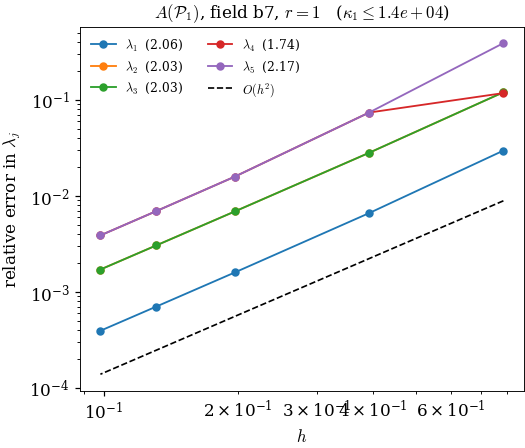

In [7]:
df = h_tables[("A(CG)", "b7")]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

# Reference slope, anchored a factor 0.30 below the lowest curve so that it sits
# beside the data rather than under it.
ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$A(\mathcal{P}_1)$, field b7, $r=1$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "bregT_h_b7_ACG.pdf")
plt.show()

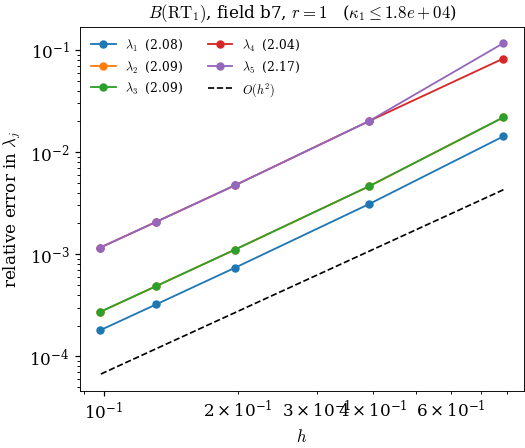

In [8]:
df = h_tables[("B(RT)", "b7")]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

# Reference slope, anchored a factor 0.30 below the lowest curve so that it sits
# beside the data rather than under it.
ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$B(\mathrm{RT}_1)$, field b7, $r=1$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "bregT_h_b7_BRT.pdf")
plt.show()

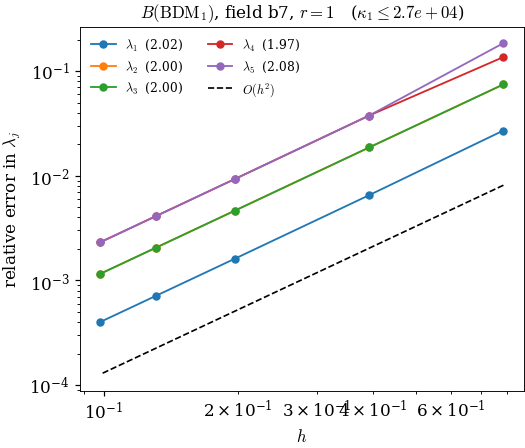

In [9]:
df = h_tables[("B(BDM)", "b7")]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

# Reference slope, anchored a factor 0.30 below the lowest curve so that it sits
# beside the data rather than under it.
ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$B(\mathrm{BDM}_1)$, field b7, $r=1$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "bregT_h_b7_BBDM.pdf")
plt.show()

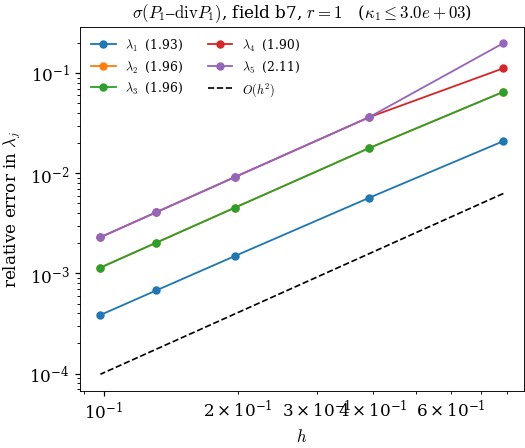

In [10]:
df = h_tables[("s(P1-divP1)", "b7")]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

# Reference slope, anchored a factor 0.30 below the lowest curve so that it sits
# beside the data rather than under it.
ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$\sigma(P_1\text{–div}P_1)$, field b7, $r=1$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "bregT_h_b7_sP1.pdf")
plt.show()

All four formulations recover $O(h^2)$ on every one of the five eigenvalues, the spurious
element included. That is the point of putting it in the same figure: **a convergence study
of the physical eigenvalues does not distinguish a polluting discretisation from a sound
one**, provided the indexing is repaired first. Its extra modes are simply not among the
five being tracked. The failure is in the count, not the rate — and Section 3.5 goes
looking for the count.

### 3.3 $p$-refinement

FEEC formulations only: $\sigma(P_1\text{–div}P_1)$ is defined at lowest order and has no
$p$ to raise.

In [11]:
P_LEVELS = (1, 2, 3, 4)
N_PREF = 8


def p_study(form, field_key, levels=P_LEVELS, N=N_PREF, Rm=1.0, alpha=None):
    ref = reference_for(field_key, alpha)
    mesh = crisscross_mesh(N)
    beta = (FIELDS[field_key](mesh) if alpha is None
            else FIELDS[field_key](mesh, alpha=alpha))
    sup = FIELDS[field_key].sup or effective_sup(mesh, beta)
    rows = []
    for r in levels:
        res = solve_form(form, mesh, N, r, beta=beta, Rm=Rm, nev=30,
                         beta_sup=sup, field=field_key)
        got = assign(ref, res.values)
        rows.append(dict(r=r, dof=res.size,
                         **{EIG_COLS[j]: abs(got[j] - ref[j]) / abs(ref[j])
                            for j in range(5)},
                         **{r"$\kappa_1$": res.kappa1}))
    return pd.DataFrame(rows).set_index("r")


p_tables = {(f, "b7"): p_study(f, "b7") for f in FEEC}
for f in FEEC:
    display(show(p_tables[(f, "b7")], default="{:.3e}",
                 rules=[("dof", "{:.0f}"), (r"$\kappa_1$", "{:.2e}")],
                 caption=rf"$p$-refinement, **{f}**, field `b7`, $N = {N_PREF}$, $R_m = 1$"))

**$p$-refinement, **A(CG)**, field `b7`, $N = 8$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,145,6.619e-03,2.811e-02,2.811e-02,7.381e-02,7.381e-02,8.21e+02
2,545,3.789e-05,1.257e-04,1.257e-04,6.483e-04,6.483e-04,4.59e+03
3,1201,1.190e-06,6.474e-07,6.474e-07,1.875e-06,1.875e-06,1.72e+04
4,2113,1.224e-07,9.730e-08,9.730e-08,2.115e-07,2.115e-07,4.01e+04


**$p$-refinement, **B(RT)**, field `b7`, $N = 8$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,656,3.098e-03,4.627e-03,4.627e-03,2.012e-02,2.012e-02,1.54e+03
2,2080,5.456e-05,8.602e-05,8.602e-05,3.699e-04,3.699e-04,1.02e+04
3,4272,1.749e-06,1.643e-06,1.643e-06,5.299e-06,5.299e-06,4.29e+04
4,7232,1.779e-07,1.426e-07,1.426e-07,3.344e-07,3.344e-07,9.04e+04


**$p$-refinement, **B(BDM)**, field `b7`, $N = 8$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,1056,6.519e-03,1.863e-02,1.863e-02,3.758e-02,3.758e-02,2.10e+03
2,2736,6.508e-06,9.766e-05,9.766e-05,4.141e-04,4.141e-04,1.11e+04
3,5184,1.606e-07,3.416e-07,3.416e-07,2.548e-06,2.548e-06,4.58e+04
4,8400,3.028e-08,2.426e-08,2.426e-08,6.218e-08,6.218e-08,1.23e+05


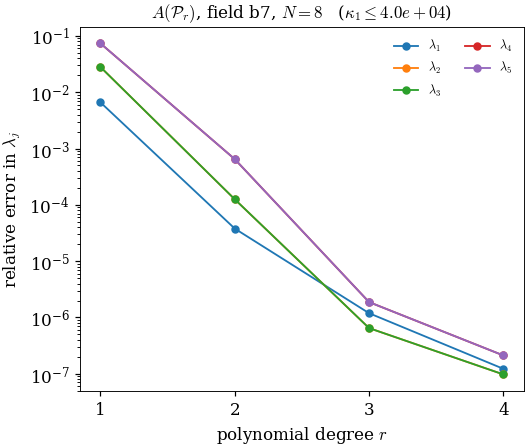

In [12]:
df = p_tables[("A(CG)", "b7")]

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.semilogy(df.index, df[EIG_COLS[0]], "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2, label=r"$\lambda_{1}$")
ax.semilogy(df.index, df[EIG_COLS[1]], "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2, label=r"$\lambda_{2}$")
ax.semilogy(df.index, df[EIG_COLS[2]], "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2, label=r"$\lambda_{3}$")
ax.semilogy(df.index, df[EIG_COLS[3]], "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2, label=r"$\lambda_{4}$")
ax.semilogy(df.index, df[EIG_COLS[4]], "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2, label=r"$\lambda_{5}$")
ax.set_xlabel(r"polynomial degree $r$")
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$A(\mathcal{P}_r)$, field b7, $N=8$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "bregT_p_b7_ACG.pdf")
plt.show()

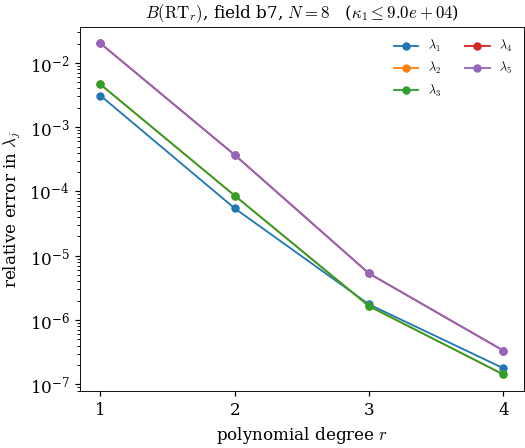

In [13]:
df = p_tables[("B(RT)", "b7")]

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.semilogy(df.index, df[EIG_COLS[0]], "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2, label=r"$\lambda_{1}$")
ax.semilogy(df.index, df[EIG_COLS[1]], "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2, label=r"$\lambda_{2}$")
ax.semilogy(df.index, df[EIG_COLS[2]], "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2, label=r"$\lambda_{3}$")
ax.semilogy(df.index, df[EIG_COLS[3]], "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2, label=r"$\lambda_{4}$")
ax.semilogy(df.index, df[EIG_COLS[4]], "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2, label=r"$\lambda_{5}$")
ax.set_xlabel(r"polynomial degree $r$")
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$B(\mathrm{RT}_r)$, field b7, $N=8$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "bregT_p_b7_BRT.pdf")
plt.show()

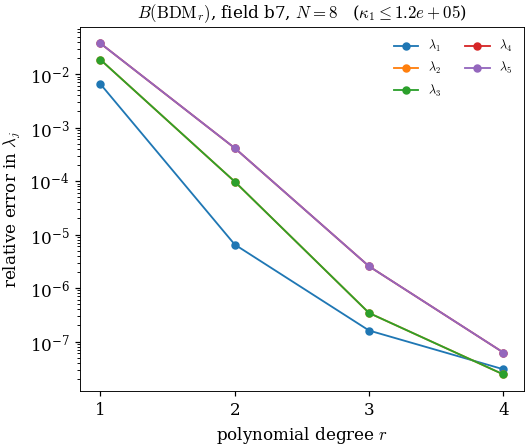

In [14]:
df = p_tables[("B(BDM)", "b7")]

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.semilogy(df.index, df[EIG_COLS[0]], "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2, label=r"$\lambda_{1}$")
ax.semilogy(df.index, df[EIG_COLS[1]], "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2, label=r"$\lambda_{2}$")
ax.semilogy(df.index, df[EIG_COLS[2]], "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2, label=r"$\lambda_{3}$")
ax.semilogy(df.index, df[EIG_COLS[3]], "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2, label=r"$\lambda_{4}$")
ax.semilogy(df.index, df[EIG_COLS[4]], "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2, label=r"$\lambda_{5}$")
ax.set_xlabel(r"polynomial degree $r$")
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$B(\mathrm{BDM}_r)$, field b7, $N=8$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "bregT_p_b7_BBDM.pdf")
plt.show()

As in the $1$-form study, exponential convergence is gone: the curves bend and the gain per
degree shrinks with $r$. Losing $W^{1,\infty}$ costs the $p$-version its main advantage,
and it does so identically in all three FEEC spaces.

### 3.4 The other fields

In [15]:
rows = []
for key in ROUGH:
    for form in H_FORMS:
        if (form, key) not in h_tables:
            h_tables[(form, key)] = h_study(form, key)
        df = h_tables[(form, key)]
        row = {"field": key, "formulation": form}
        for col in EIG_COLS:
            row[f"rate {col}"] = rates(df["h"], df[col])[-1]
        row[r"$\kappa_1$ (finest)"] = df[r"$\kappa_1$"].iloc[-1]
        rows.append(row)
show(pd.DataFrame(rows).set_index(["field", "formulation"]), default="{:.2f}",
     rules=[(r"$\kappa_1$ (finest)", "{:.2e}")],
     caption=r"Observed $h$-refinement orders at the finest level, all three "
             r"$L^\infty\setminus W^{1,\infty}$ fields and all four lowest-order "
             r"discretisations ($r = 1$, $R_m = 1$)")

**Observed $h$-refinement orders at the finest level, all three $L^\infty\setminus W^{1,\infty}$ fields and all four lowest-order discretisations ($r = 1$, $R_m = 1$)**

rate $\lambda_{1}$ rate $\lambda_{2}$ rate $\lambda_{3}$  \
field formulation                                                            
b6    A(CG)                     2.01               2.01               2.00   
      B(RT)                     2.00               2.00               2.00   
      B(BDM)                    2.00               2.00               2.00   
      s(P1-divP1)               2.00               2.00               2.00   
b7    A(CG)                     2.01               2.01               2.01   
      B(RT)                     2.02               2.01               2.01   
      B(BDM)                    2.00               2.00               2.00   
      s(P1-divP1)               1.96               1.99               1.99   
b8    A(CG)                     2.04               2.01               2.01   
      B(RT)                     2.01               2.01               2.01   
      B(BDM)                    2.01               2.00               2.00   
      s(P1-divP1)               1.94               1.99               1.99   

                  rate $\lambda_{4}$ rate $\lambda_{5}$ $\kappa_1$ (finest)  
field formulation                                                            
b6    A(CG)                     2.01               2.00            3.43e+03  
      B(RT)                     2.00               2.02            4.58e+03  
      B(BDM)                    2.00               2.00            6.77e+03  
      s(P1-divP1)               2.00               2.00            7.60e+02  
b7    A(CG)                     2.02               2.02            1.36e+04  
      B(RT)                     2.01               2.01            1.83e+04  
      B(BDM)                    2.00               2.00            2.69e+04  
      s(P1-divP1)               1.99               1.99            2.97e+03  
b8    A(CG)                     1.65               1.94            3.08e+03  
      B(RT)                     1.94               1.89            4.15e+03  
      B(BDM)                    2.44               1.98            6.14e+03  
      s(P1-divP1)               2.44               1.97            8.45e+02

The other fields behave the same way, so the panels of Section 3.2 are representative and
the remaining curves belong in an appendix. As in the $1$-form case the differences between
fields live in the constants rather than the orders, and the least structured field carries
the largest ones.

### 3.5 Does the spurious branch survive the loss of regularity?

This is the question only the top-form setting can ask. In the diffusive limit the
$\sigma(P_1\text{–div}P_1)$ element produces a complete **shadow spectrum** at
$3\varepsilon(m^2+n^2)$ — one extra mode for every genuine one, with the same
multiplicities. What becomes of it when $\beta$ is rough?

Extra eigenvalues are found by matching the polluting spectrum against $B(\mathrm{BDM}_1)$
on the *same* mesh, so the comparison carries the same discretisation error on both sides.

In [16]:
N_SP = 24
mesh_sp = crisscross_mesh(N_SP)


def spurious_set(field_key, Rm=1.0, alpha=None, n_test=25, rtol=3e-3):
    """Values in the polluting spectrum with no counterpart in B(BDM) on the same mesh."""
    beta = (None if field_key == "b0" else
            (FIELDS[field_key](mesh_sp) if alpha is None
             else FIELDS[field_key](mesh_sp, alpha=alpha)))
    sup = 1.0 if beta is None else (FIELDS[field_key].sup
                                    or effective_sup(mesh_sp, beta))
    ref = solve_form("B(BDM)", mesh_sp, N_SP, 1, beta=beta, Rm=Rm, nev=45,
                     beta_sup=sup, field=field_key)
    bad = solve_form("s(P1-divP1)", mesh_sp, N_SP, 1, beta=beta, Rm=Rm, nev=45,
                     beta_sup=sup, field=field_key)
    extra = np.array([z for z in bad.values[:n_test]
                      if np.min(np.abs(ref.values - z)) > rtol * max(1.0, abs(z))])
    return ref, bad, extra


rows = []
for key in ["b0"] + ROUGH + ["b9"]:
    alpha = 1.5 if key == "b9" else None
    ref, bad, extra = spurious_set(key, alpha=alpha)
    rows.append(dict(
        field=key, **{
            r"genuine $\lambda_1$": ref.values[0],
            r"genuine $\lambda_2$": ref.values[1],
            r"1st spurious": extra[0] if len(extra) else None,
            r"2nd spurious": extra[1] if len(extra) > 1 else None,
            r"$3\lambda_1$": 3 * ref.values[0],
            "n spurious in 25": len(extra),
            r"$\kappa_1$": bad.kappa1}))
show(pd.DataFrame(rows).set_index("field"), default="{:.4f}",
     rules=[("n spurious", "{:.0f}"), (r"$\kappa_1$", "{:.2e}")],
     caption=rf"The shadow spectrum under each field, $R_m = 1$, $N = {N_SP}$, $r = 1$ "
             rf"(`b0` is the diffusive limit, `b9` has $\alpha = 1.5$)")

**The shadow spectrum under each field, $R_m = 1$, $N = 24$, $r = 1$ (`b0` is the diffusive limit, `b9` has $\alpha = 1.5$)**

,genuine $\lambda_1$,genuine $\lambda_2$,1st spurious,2nd spurious,$3\lambda_1$,n spurious in 25,$\kappa_1$
field,,,,,,,
b0,2.0019,5.0119,5.9914,14.8715,6.0057,6,3.35e+03
b6,2.7976,5.2588,6.6751,14.9545,8.3928,6,5.82e+02
b7,2.0996,5.15302+0.72796i,6.0247,14.92003+0.71319i,6.2987,5,2.26e+03
b8,2.9117,5.68606+0.65922i,6.7103,15.29920+0.64707i,8.7352,5,5.67e+02
b9,2.0032,5.11408+1.35050i,5.9948,14.90914+1.34066i,6.0095,6,4.72e+03


In [17]:
print("imaginary parts: does a spurious mode inherit the genuine one's?\n")
for key in ROUGH + ["b9"]:
    alpha = 1.5 if key == "b9" else None
    ref, bad, extra = spurious_set(key, alpha=alpha)
    cx = [z for z in extra if abs(z.imag) > 1e-8]
    if not cx:
        print(f"  {key}: no complex spurious value in the window")
        continue
    z = cx[0]
    partner = ref.values[int(np.argmin(np.abs(ref.values.imag - z.imag)))]
    print(f"  {key}: spurious {z.real:8.4f}{z.imag:+8.4f}i   "
          f"nearest genuine Im: {partner.real:8.4f}{partner.imag:+8.4f}i   "
          f"|Im ratio| = {abs(z.imag / partner.imag):.3f}")

imaginary parts: does a spurious mode inherit the genuine one's?



  b6: no complex spurious value in the window


  b7: spurious  14.9200 +0.7132i   nearest genuine Im:   5.1530 +0.7280i   |Im ratio| = 0.980


  b8: spurious  15.2992 +0.6471i   nearest genuine Im:   5.6861 +0.6592i   |Im ratio| = 0.982


  b9: spurious  14.9091 +1.3407i   nearest genuine Im:   5.1141 +1.3505i   |Im ratio| = 0.993


Two clear findings, and they pull in opposite directions.

**The shadow spectrum survives every field.** The first spurious value stays between $5.99$
and $6.71$ across the whole set — a $12\%$ excursion — while the genuine $\lambda_1$ moves
from $2.00$ to $2.91$, which is $45\%$. The pollution is *anchored*: roughening $\beta$ moves
it about four times less than it moves the physical spectrum, does not disperse it into the
physical cluster, and does not remove it. The count of extra values in the first twenty-five
is essentially unchanged (six, five for the two least regular fields, the difference being
one value crossing the edge of the window).

**But the $3\times$ rule does not survive.** In the diffusive limit the spurious values are
exactly three times the genuine ones, and the $3\lambda_1$ column shows how far that breaks
under advection: for `b8` it predicts $8.7$ where the observed spurious value is $6.7$. What
is tripled is the *diffusive* part of the eigenvalue; the advective correction is not.

The imaginary parts make the same point sharply. A complex spurious value carries an
imaginary part within $2\%$ of the genuine mode it shadows — the measured ratios are
$0.980$, $0.982$ and $0.993$ for `b7`, `b8` and `b9`, i.e. near $1$ and nowhere near $3$. A
spurious mode is therefore transported by the wind at very nearly the same rate as a real
one, which is precisely why advection camouflages pollution rather than exposing it.

### 3.6 An expanded spectral window

In [18]:
PS_N, PS_NEV = 20, 80
PS_WINDOW = ((0.0, 32.0), (-6.0, 6.0))
mesh_ps = crisscross_mesh(PS_N)


def run_ps(form, field_key, Rm=1.0, alpha=None, window=PS_WINDOW, nev=PS_NEV, r=1):
    """Assemble one pencil and hand it to the pseudospectrum engine."""
    beta = (None if field_key == "b0" else
            (FIELDS[field_key](mesh_ps) if alpha is None
             else FIELDS[field_key](mesh_ps, alpha=alpha)))
    sup = 1.0 if beta is None else (FIELDS[field_key].sup
                                    or effective_sup(mesh_ps, beta))
    # nu = 0 here so the Ritz values are lambda itself; the shift is inert (3.1).
    A, M, W = build_pencil(form, mesh_ps, PS_N, r, beta=beta,
                           eps=Constant(1.0 / Rm), nu=0.0)
    kap = condition_estimates(A, M, 1.9 / Rm)
    out = ps.pseudospectrum(A, M, 1.9 / Rm, nev=nev, window=window,
                            form=form, beta=field_key, Rm=Rm, alpha=alpha,
                            label=FIELDS[field_key].tex if field_key != "b0" else r"$\beta=0$")
    out["kappa1"] = kap[r"Hager $\kappa_1$"]
    return out


ps_wide = {f: run_ps(f, "b7") for f in ["B(BDM)", "s(P1-divP1)"]}
show(ps.diagnostics_frame(ps_wide.values(), keys=("form", "beta")), default="{:.3e}",
     rules=[("N", "{:.0f}"), ("m", "{:.0f}"), ("eigs in window", "{:.0f}")],
     caption=rf"Projection diagnostics for the wide-window scan, field `b7`, "
             rf"$N = {PS_N}$, nev $= {PS_NEV}$")

**Projection diagnostics for the wide-window scan, field `b7`, $N = 20$, nev $= 80$**

,,N,m,QZ residual,max |Im| in window,max |Im| all ritz,window fidelity,eigs in window
form,beta,,,,,,,
B(BDM),b7,6480,91,7.106e-15,2,5,3.055e-13,19
s(P1-divP1),b7,2882,83,6.425e-17,2,3,1.684e-12,25


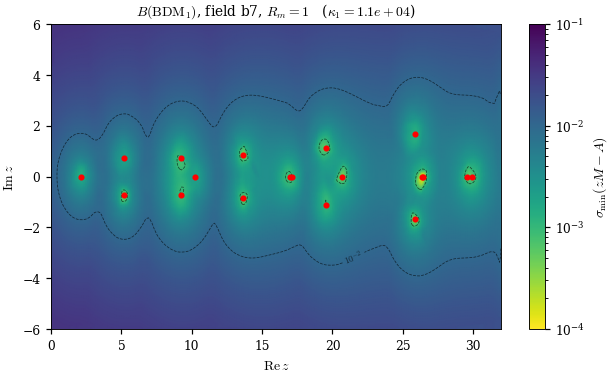

In [19]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(6.6, 3.6))
    r_ = ps_wide["B(BDM)"]
    ps.plot_pseudospectrum(r_, ax=ax,
                           title=r"$B(\mathrm{BDM}_1)$, field b7, $R_m=1$"
                                 + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "bregT_ps_wide_b7_BBDM.pdf")
    plt.show()

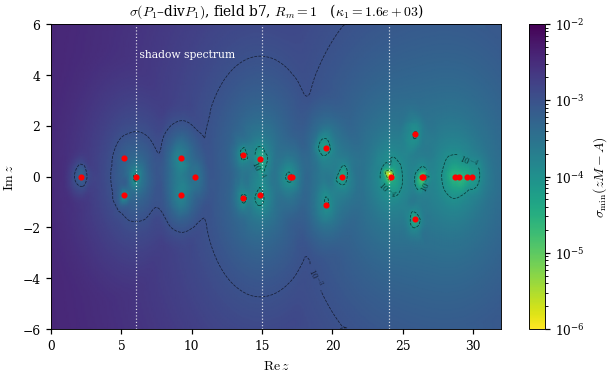

In [20]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(6.6, 3.6))
    r_ = ps_wide["s(P1-divP1)"]
    ax = ps.plot_pseudospectrum(r_, ax=ax,
                                title=r"$\sigma(P_1$–div$P_1)$, field b7, $R_m=1$"
                                      + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    for value in (6.0, 15.0, 24.0):
        ax.axvline(value, color="w", lw=0.8, ls=":", alpha=0.8)
    ax.text(6.0, 5.0, r" shadow spectrum", color="w", fontsize=7, va="top")
    fig.savefig(FIGDIR / "bregT_ps_wide_b7_sP1.pdf")
    plt.show()

Side by side over a window covering roughly the first thirty modes, the difference is
plain: the polluting panel carries wells at $6$, $15$ and $24$ that the FEEC panel does not,
and they are as deep and as tight as the genuine ones beside them. The resolvent cannot
tell them apart — a spurious value *is* an eigenvalue of the discrete pencil, so
$\sigma_{\min}(zM-A)$ must vanish there — which is why the paired comparison, rather than
any single-discretisation diagnostic, is what finds it.

### 3.7 Convergence rates as $R_m$ varies

In [21]:
RM_LEVELS = (16, 24, 32, 40)
RM_VALUES = (1.0, 2.0, 5.0, 10.0)

print("cell Peclet at the coarsest level used:")
for Rm in RM_VALUES:
    print(f"  Rm = {Rm:5.1f}:  {(np.pi / RM_LEVELS[0]) * FIELDS['b7'].sup * Rm / 2:.2f}")

REFERENCE_RM = {}
for Rm in RM_VALUES:
    beta_r = FIELDS["b7"](mesh_ref)
    stack = np.array([solve_form(f, mesh_ref, N_REF, R_REF, beta=beta_r, Rm=Rm,
                                 nev=NEV_REF, n_eigs=5, beta_sup=1.0,
                                 field="b7").values[:5] for f in FEEC])
    REFERENCE_RM[Rm] = stack.mean(axis=0)
    print(f"  Rm = {Rm:5.1f}: reference lambda_1..3 = {np.round(stack.mean(axis=0)[:3], 6)}"
          f"   spread {spread(stack).max():.1e}")

cell Peclet at the coarsest level used:
  Rm =   1.0:  0.10
  Rm =   2.0:  0.20
  Rm =   5.0:  0.49
  Rm =  10.0:  0.98


  Rm =   1.0: reference lambda_1..3 = [2.098061+0.j       5.142336+0.727567j 5.142336-0.727567j]   spread 6.0e-07


  Rm =   2.0: reference lambda_1..3 = [1.18783+0.j       2.77379+0.745109j 2.77379-0.745109j]   spread 1.0e-06


  Rm =   5.0: reference lambda_1..3 = [0.776618+0.j       1.57905 +0.807924j 1.57905 -0.807924j]   spread 5.7e-06


  Rm =  10.0: reference lambda_1..3 = [0.709623+0.j       1.358871+0.890481j 1.358871-0.890481j]   spread 3.7e-05


In [22]:
rows = []
for Rm in RM_VALUES:
    ref = REFERENCE_RM[Rm]
    for form in H_FORMS:
        errs, kap = [], []
        for N in RM_LEVELS:
            mesh = crisscross_mesh(N)
            res = solve_form(form, mesh, N, 1, beta=FIELDS["b7"](mesh), Rm=Rm,
                             nev=30, beta_sup=1.0, field="b7")
            got = assign(ref, res.values)
            errs.append([abs(got[j] - ref[j]) / abs(ref[j]) for j in range(5)])
            kap.append(res.kappa1)
        errs = np.array(errs)
        h = np.pi / np.array(RM_LEVELS, dtype=float)
        per_mode = np.array([rates(h, errs[:, j])[-1] for j in range(5)])
        rows.append(dict(Rm=Rm, formulation=form,
                         **{r"rate $\lambda_1$": per_mode[0],
                            "mean rate": per_mode.mean(),
                            "min rate": per_mode.min(),
                            r"$\kappa_1$ (finest)": kap[-1]}))
show(pd.DataFrame(rows).set_index(["Rm", "formulation"]), default="{:.2f}",
     rules=[(r"$\kappa_1$ (finest)", "{:.2e}"), ("Rm", "{:.1f}")],
     caption=r"Observed $h$-refinement orders for the first five eigenvalues as $R_m$ "
             r"varies, field `b7`, $r = 1$")

**Observed $h$-refinement orders for the first five eigenvalues as $R_m$ varies, field `b7`, $r = 1$**

rate $\lambda_1$ mean rate min rate $\kappa_1$ (finest)
Rm   formulation                                                        
1.0  A(CG)                   2.01      2.01     2.00            2.13e+04
     B(RT)                   2.01      2.01     2.01            2.80e+04
     B(BDM)                  2.00      2.00     2.00            4.13e+04
     s(P1-divP1)             1.97      1.99     1.97            3.68e+03
2.0  A(CG)                   1.96      2.00     1.96            9.16e+03
     B(RT)                   1.86      1.99     1.86            3.29e+04
     B(BDM)                  2.03      2.01     2.00            6.08e+04
     s(P1-divP1)             1.08      1.79     1.08            2.52e+03
5.0  A(CG)                   1.95      1.96     1.95            2.49e+03
     B(RT)                   1.93      1.91     1.90            4.10e+04
     B(BDM)                  1.95      1.95     1.95            1.01e+05
     s(P1-divP1)             2.23      2.21     2.18            1.61e+03
10.0 A(CG)                   1.87      1.89     1.87            1.33e+03
     B(RT)                   1.85      1.83     1.81            6.31e+04
     B(BDM)                  1.84      1.88     1.84            1.75e+05
     s(P1-divP1)             2.22      2.19     2.17            1.55e+03

The order is robust across two decades of $R_m$ in every discretisation — including the
polluting one, whose genuine modes remain as accurate as anybody's. Accuracy falls with
$R_m$ but the rate does not, provided the cell Péclet bound is respected.

<a id="4"></a>
## 4. Fields in $L^p$

The $L^\infty$ bound on $\beta$ is what makes the advective bilinear form bounded and the
inf–sup argument go through. The vortex $\beta_9$ leaves that hypothesis behind, with
$\alpha$ as a continuous dial: $|\beta_9| = r_c^{\,1-\alpha}$, bounded at $\alpha = 1$ and
approaching the edge of $L^2$ as $\alpha \to 2$.

Because $\beta$ is unbounded there is no mesh-independent $\|\beta\|_{L^\infty}$ and hence
no mesh-independent cell Péclet number. What the discretisation sees is reported instead.

In [23]:
ALPHAS = (1.0, 1.25, 1.5, 1.75)
ALPHA_MAIN = 1.5

print("effective magnitude of the vortex, by mesh and exponent")
print(f"{'N':>5s}" + "".join(f"{'a=' + format(a, '.2f'):>12s}" for a in ALPHAS))
for N in (8, 16, 32):
    mesh_e = crisscross_mesh(N)
    line = f"{N:5d}"
    for a in ALPHAS:
        line += f"{effective_sup(mesh_e, FIELDS['b9'](mesh_e, alpha=a)):12.2f}"
    print(line)

effective magnitude of the vortex, by mesh and exponent
    N      a=1.00      a=1.25      a=1.50      a=1.75


    8        1.00        1.48        2.20        3.26
   16        1.00        1.76        3.11        5.48
   32        1.00        2.10        4.40        9.22


In [24]:
mesh_ref_lp = crisscross_mesh(N_REF)
ref_runs_lp = {}
for a in ALPHAS:
    beta_a = FIELDS["b9"](mesh_ref_lp, alpha=a)
    sup_a = effective_sup(mesh_ref_lp, beta_a)
    for form in FEEC:
        ref_runs_lp[(a, form)] = solve_form(form, mesh_ref_lp, N_REF, R_REF,
                                            beta=beta_a, nev=NEV_REF, n_eigs=5,
                                            beta_sup=sup_a, field="b9", alpha=a)
    stack = np.array([ref_runs_lp[(a, f)].values[:5] for f in FEEC])
    REFERENCE_LP[("b9", a)] = stack.mean(axis=0)

rows = []
for a in ALPHAS:
    stack = np.array([ref_runs_lp[(a, f)].values[:5] for f in FEEC])
    rows.append(dict(alpha=a,
                     **{r"$p$ limit": (2.0 / (a - 1.0)) if a > 1.0 else np.inf,
                        r"$\lambda_1$": stack.mean(axis=0)[0],
                        r"$\lambda_2$": stack.mean(axis=0)[1],
                        "max spread": spread(stack).max(),
                        "min digits": min(agreeing_digits(stack[:, j])
                                          for j in range(5)),
                        r"$\kappa_1$ B(RT)": ref_runs_lp[(a, "B(RT)")].kappa1}))
show(pd.DataFrame(rows).set_index("alpha"), default="{:.6f}",
     rules=[("alpha", "{:.2f}"), (r"$p$ limit", "{:.2f}"), ("max spread", "{:.2e}"),
            ("min digits", "{:.0f}"), (r"$\kappa_1$ B(RT)", "{:.2e}")],
     caption=rf"Cross-validation for the $L^p$ vortex over the FEEC formulations, "
             rf"$R_m = 1$, $N = {N_REF}$, $r = {R_REF}$")

**Cross-validation for the $L^p$ vortex over the FEEC formulations, $R_m = 1$, $N = 24$, $r = 3$**

,$p$ limit,$\lambda_1$,$\lambda_2$,max spread,min digits,$\kappa_1$ B(RT)
alpha,,,,,,
1.00,--,2.001785,5.04123+1.16018i,3.19e-08,8,6.84e+05
1.25,8.00,2.001517,5.06293+1.24510i,9.29e-08,7,6.87e+05
1.50,4.00,2.001295,5.10245+1.34954i,1.67e-06,6,6.90e+05
1.75,2.67,2.001112,5.17198+1.47026i,2.47e-05,5,6.96e+05


Agreement degrades monotonically with the strength of the singularity, exactly as in the
$1$-form study, and the conditioning is untouched by $\alpha$. Whatever is being lost, it is
not the linear algebra.

### 4.2 The shadow spectrum against the singularity

Before the convergence studies, the question that is peculiar to this notebook: does the
strength of the singularity move the pollution?

In [25]:
rows = []
for a in ALPHAS:
    ref, bad, extra = spurious_set("b9", alpha=a)
    rows.append(dict(alpha=a,
                     **{r"genuine $\lambda_1$": ref.values[0],
                        r"1st spurious": extra[0] if len(extra) else None,
                        r"2nd spurious": extra[1] if len(extra) > 1 else None,
                        r"$3\lambda_1$": 3 * ref.values[0],
                        "n spurious in 25": len(extra),
                        r"$\kappa_1$": bad.kappa1}))
show(pd.DataFrame(rows).set_index("alpha"), default="{:.4f}",
     rules=[("alpha", "{:.2f}"), ("n spurious", "{:.0f}"), (r"$\kappa_1$", "{:.2e}")],
     caption=rf"The shadow spectrum against the strength of the singularity, "
             rf"$R_m = 1$, $N = {N_SP}$, $r = 1$")

**The shadow spectrum against the strength of the singularity, $R_m = 1$, $N = 24$, $r = 1$**

,genuine $\lambda_1$,1st spurious,2nd spurious,$3\lambda_1$,n spurious in 25,$\kappa_1$
alpha,,,,,,
1.00,2.0037,5.9937,14.88888+1.14469i,6.0110,6,4.41e+03
1.25,2.0034,5.9940,14.89597+1.23063i,6.0102,6,3.97e+03
1.50,2.0032,5.9948,14.90914+1.34066i,6.0095,6,4.12e+03
1.75,2.0030,5.9968,14.93369+1.48137i,6.0090,6,4.35e+03


**The pollution is indifferent to the singularity.** The first spurious value stays pinned
near $6$ across the whole range of $\alpha$, the count of extra modes in the first
twenty-five does not change, and the conditioning is flat. Roughening $\beta$ — even to the
point of unboundedness — neither creates pollution in a sound discretisation nor removes it
from a broken one. It is a property of the *space pair*, not of the data.

### 4.3 $h$- and $p$-refinement

In [26]:
h_tables_lp = {f: h_study(f, "b9", alpha=ALPHA_MAIN) for f in H_FORMS}
for f in H_FORMS:
    display(show(rate_frame(h_tables_lp[f], EIG_COLS), default="{:.3e}",
                 rules=[("rate", "{:.2f}"), ("h", "{:.5f}"), (r"$\kappa_1$", "{:.2e}")],
                 caption=rf"$h$-refinement, **{f}**, vortex $\alpha = {ALPHA_MAIN}$, "
                         rf"$r = 1$, $R_m = 1$"))

**$h$-refinement, **A(CG)**, vortex $\alpha = 1.5$, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,4.351e-02,--,1.170e-01,--,1.170e-01,--,2.551e-01,--,2.551e-01,--,2.43e+02
8,0.39270,1.064e-02,2.03,2.789e-02,2.07,2.789e-02,2.07,6.003e-02,2.09,6.003e-02,2.09,1.42e+03
16,0.19635,2.644e-03,2.01,6.934e-03,2.01,6.934e-03,2.01,1.457e-02,2.04,1.457e-02,2.04,6.36e+03
24,0.13090,1.174e-03,2.00,3.081e-03,2.00,3.081e-03,2.00,6.439e-03,2.01,6.439e-03,2.01,1.46e+04
32,0.09817,6.599e-04,2.00,1.734e-03,2.00,1.734e-03,2.00,3.615e-03,2.01,3.615e-03,2.01,2.63e+04


**$h$-refinement, **B(RT)**, vortex $\alpha = 1.5$, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,1.753e-02,--,1.295e-02,--,1.295e-02,--,8.123e-02,--,8.123e-02,--,1.47e+03
8,0.39270,4.463e-03,1.97,5.566e-03,1.22,5.566e-03,1.22,1.606e-02,2.34,1.606e-02,2.34,3.25e+03
16,0.19635,1.121e-03,1.99,1.674e-03,1.73,1.674e-03,1.73,3.865e-03,2.06,3.865e-03,2.06,1.01e+04
24,0.13090,4.988e-04,2.00,7.920e-04,1.85,7.920e-04,1.85,1.707e-03,2.01,1.707e-03,2.01,2.11e+04
32,0.09817,2.806e-04,2.00,4.608e-04,1.88,4.608e-04,1.88,9.586e-04,2.01,9.586e-04,2.01,3.60e+04


**$h$-refinement, **B(BDM)**, vortex $\alpha = 1.5$, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,3.399e-02,--,8.527e-02,--,8.527e-02,--,1.428e-01,--,1.428e-01,--,9.78e+02
8,0.39270,8.481e-03,2.00,2.084e-02,2.03,2.084e-02,2.03,3.675e-02,1.96,3.675e-02,1.96,3.93e+03
16,0.19635,2.119e-03,2.00,5.055e-03,2.04,5.055e-03,2.04,9.181e-03,2.00,9.181e-03,2.00,1.43e+04
24,0.13090,9.416e-04,2.00,2.212e-03,2.04,2.212e-03,2.04,4.079e-03,2.00,4.079e-03,2.00,3.05e+04
32,0.09817,5.296e-04,2.00,1.232e-03,2.03,1.232e-03,2.03,2.294e-03,2.00,2.294e-03,2.00,5.26e+04


**$h$-refinement, **s(P1-divP1)**, vortex $\alpha = 1.5$, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,3.207e-02,--,7.700e-02,--,7.700e-02,--,1.263e-01,--,1.263e-01,--,4.89e+02
8,0.39270,8.399e-03,1.93,2.048e-02,1.91,2.048e-02,1.91,3.657e-02,1.79,3.657e-02,1.79,1.30e+03
16,0.19635,2.115e-03,1.99,5.031e-03,2.03,5.031e-03,2.03,9.168e-03,2.00,9.168e-03,2.00,3.16e+03
24,0.13090,9.409e-04,2.00,2.206e-03,2.03,2.206e-03,2.03,4.076e-03,2.00,4.076e-03,2.00,4.72e+03
32,0.09817,5.294e-04,2.00,1.230e-03,2.03,1.230e-03,2.03,2.293e-03,2.00,2.293e-03,2.00,6.26e+03


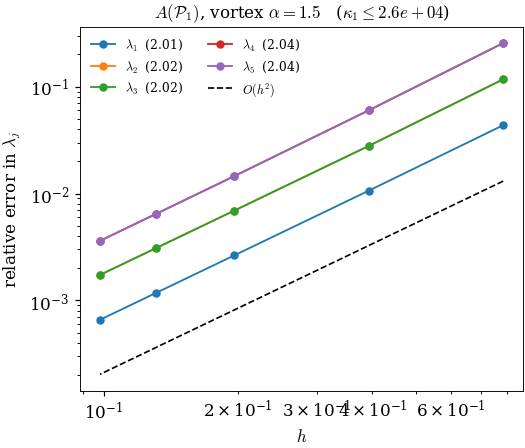

In [27]:
df = h_tables_lp["A(CG)"]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$A(\mathcal{P}_1)$, vortex $\alpha=1.5$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "bregT_h_b9_ACG.pdf")
plt.show()

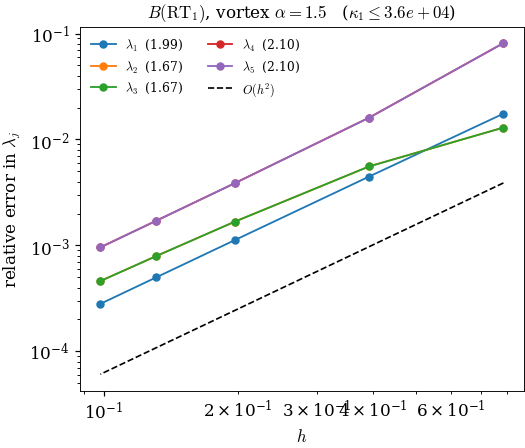

In [28]:
df = h_tables_lp["B(RT)"]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$B(\mathrm{RT}_1)$, vortex $\alpha=1.5$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "bregT_h_b9_BRT.pdf")
plt.show()

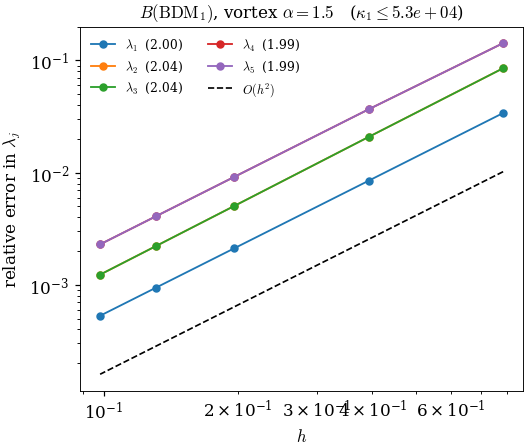

In [29]:
df = h_tables_lp["B(BDM)"]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$B(\mathrm{BDM}_1)$, vortex $\alpha=1.5$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "bregT_h_b9_BBDM.pdf")
plt.show()

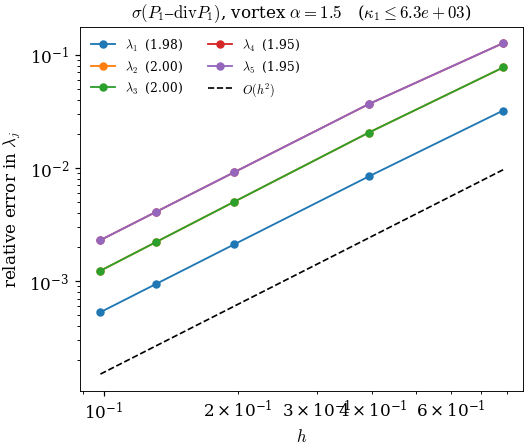

In [30]:
df = h_tables_lp["s(P1-divP1)"]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$\sigma(P_1\text{–div}P_1)$, vortex $\alpha=1.5$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "bregT_h_b9_sP1.pdf")
plt.show()

In [31]:
p_tables_lp = {f: p_study(f, "b9", alpha=ALPHA_MAIN) for f in FEEC}
for f in FEEC:
    display(show(p_tables_lp[f], default="{:.3e}",
                 rules=[("dof", "{:.0f}"), (r"$\kappa_1$", "{:.2e}")],
                 caption=rf"$p$-refinement, **{f}**, vortex $\alpha = {ALPHA_MAIN}$, "
                         rf"$N = {N_PREF}$, $R_m = 1$"))

**$p$-refinement, **A(CG)**, vortex $\alpha = 1.5$, $N = 8$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,145,1.064e-02,2.789e-02,2.789e-02,6.003e-02,6.003e-02,1.43e+03
2,545,2.426e-05,2.145e-04,2.145e-04,6.690e-04,6.690e-04,8.90e+03
3,1201,9.936e-09,6.208e-06,6.208e-06,3.579e-06,3.579e-06,3.34e+04
4,2113,1.508e-09,1.127e-06,1.127e-06,2.898e-08,2.898e-08,7.90e+04


**$p$-refinement, **B(RT)**, vortex $\alpha = 1.5$, $N = 8$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,656,4.463e-03,5.566e-03,5.566e-03,1.606e-02,1.606e-02,3.25e+03
2,2080,1.785e-06,5.645e-05,5.645e-05,1.942e-04,1.942e-04,2.04e+04
3,4272,1.687e-07,3.902e-06,3.902e-06,1.311e-06,1.311e-06,8.52e+04
4,7232,7.852e-09,3.016e-07,3.016e-07,3.011e-08,3.011e-08,1.78e+05


**$p$-refinement, **B(BDM)**, vortex $\alpha = 1.5$, $N = 8$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,1056,8.481e-03,2.084e-02,2.084e-02,3.675e-02,3.675e-02,3.93e+03
2,2736,1.883e-05,1.369e-04,1.369e-04,4.115e-04,4.115e-04,2.24e+04
3,5184,6.284e-09,3.664e-06,3.664e-06,2.219e-06,2.219e-06,9.21e+04
4,8400,2.962e-10,3.231e-07,3.231e-07,1.387e-08,1.387e-08,2.46e+05


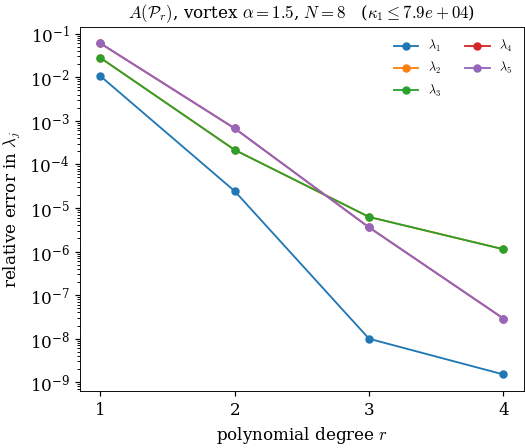

In [32]:
df = p_tables_lp["A(CG)"]

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.semilogy(df.index, df[EIG_COLS[0]], "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2, label=r"$\lambda_{1}$")
ax.semilogy(df.index, df[EIG_COLS[1]], "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2, label=r"$\lambda_{2}$")
ax.semilogy(df.index, df[EIG_COLS[2]], "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2, label=r"$\lambda_{3}$")
ax.semilogy(df.index, df[EIG_COLS[3]], "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2, label=r"$\lambda_{4}$")
ax.semilogy(df.index, df[EIG_COLS[4]], "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2, label=r"$\lambda_{5}$")
ax.set_xlabel(r"polynomial degree $r$")
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$A(\mathcal{P}_r)$, vortex $\alpha=1.5$, $N=8$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "bregT_p_b9_ACG.pdf")
plt.show()

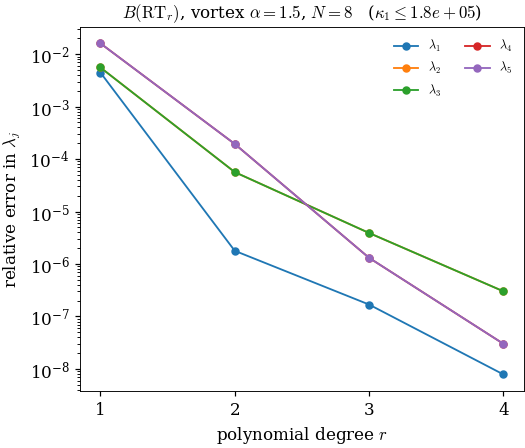

In [33]:
df = p_tables_lp["B(RT)"]

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.semilogy(df.index, df[EIG_COLS[0]], "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2, label=r"$\lambda_{1}$")
ax.semilogy(df.index, df[EIG_COLS[1]], "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2, label=r"$\lambda_{2}$")
ax.semilogy(df.index, df[EIG_COLS[2]], "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2, label=r"$\lambda_{3}$")
ax.semilogy(df.index, df[EIG_COLS[3]], "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2, label=r"$\lambda_{4}$")
ax.semilogy(df.index, df[EIG_COLS[4]], "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2, label=r"$\lambda_{5}$")
ax.set_xlabel(r"polynomial degree $r$")
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$B(\mathrm{RT}_r)$, vortex $\alpha=1.5$, $N=8$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "bregT_p_b9_BRT.pdf")
plt.show()

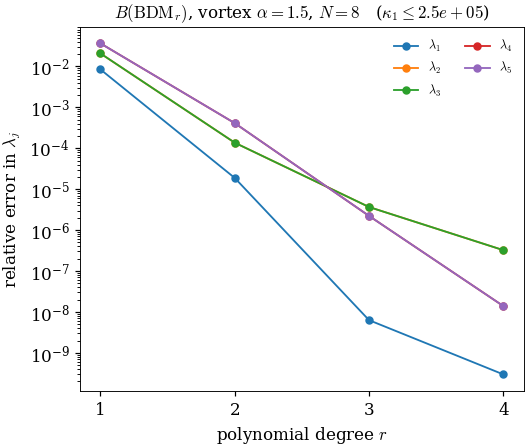

In [34]:
df = p_tables_lp["B(BDM)"]

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.semilogy(df.index, df[EIG_COLS[0]], "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2, label=r"$\lambda_{1}$")
ax.semilogy(df.index, df[EIG_COLS[1]], "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2, label=r"$\lambda_{2}$")
ax.semilogy(df.index, df[EIG_COLS[2]], "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2, label=r"$\lambda_{3}$")
ax.semilogy(df.index, df[EIG_COLS[3]], "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2, label=r"$\lambda_{4}$")
ax.semilogy(df.index, df[EIG_COLS[4]], "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2, label=r"$\lambda_{5}$")
ax.set_xlabel(r"polynomial degree $r$")
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$B(\mathrm{BDM}_r)$, vortex $\alpha=1.5$, $N=8$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "bregT_p_b9_BBDM.pdf")
plt.show()

The $h$-rates hold at $O(h^2)$ for the vortex in every discretisation, the polluting one
included; a point singularity has measure zero and does not by itself destroy the order of
the eigenvalues. $p$-refinement is again the casualty — the gain per degree is smaller than
for the $L^\infty$ fields and flattens earlier, because the error is controlled by a
neighbourhood of one point that only $h$-refinement resolves. **For $L^p$ data, refine $h$
before raising $r$.**

### 4.4 Convergence as $R_m$ varies

In [35]:
RM_VALUES_LP = (1.0, 2.0, 5.0)
REFERENCE_RM_LP = {}
for Rm in RM_VALUES_LP:
    beta_a = FIELDS["b9"](mesh_ref_lp, alpha=ALPHA_MAIN)
    sup_a = effective_sup(mesh_ref_lp, beta_a)
    stack = np.array([solve_form(f, mesh_ref_lp, N_REF, R_REF, beta=beta_a, Rm=Rm,
                                 nev=NEV_REF, n_eigs=5, beta_sup=sup_a,
                                 field="b9").values[:5] for f in FEEC])
    REFERENCE_RM_LP[Rm] = stack.mean(axis=0)

rows = []
for Rm in RM_VALUES_LP:
    ref = REFERENCE_RM_LP[Rm]
    for form in H_FORMS:
        errs, kap = [], []
        for N in RM_LEVELS:
            mesh = crisscross_mesh(N)
            beta = FIELDS["b9"](mesh, alpha=ALPHA_MAIN)
            res = solve_form(form, mesh, N, 1, beta=beta, Rm=Rm, nev=30,
                             beta_sup=effective_sup(mesh, beta), field="b9")
            got = assign(ref, res.values)
            errs.append([abs(got[j] - ref[j]) / abs(ref[j]) for j in range(5)])
            kap.append(res.kappa1)
        errs = np.array(errs)
        h = np.pi / np.array(RM_LEVELS, dtype=float)
        per_mode = np.array([rates(h, errs[:, j])[-1] for j in range(5)])
        rows.append(dict(Rm=Rm, formulation=form,
                         **{r"rate $\lambda_1$": per_mode[0],
                            "mean rate": per_mode.mean(),
                            "min rate": per_mode.min(),
                            r"$\kappa_1$ (finest)": kap[-1]}))
show(pd.DataFrame(rows).set_index(["Rm", "formulation"]), default="{:.2f}",
     rules=[(r"$\kappa_1$ (finest)", "{:.2e}"), ("Rm", "{:.1f}")],
     caption=rf"Observed $h$-refinement orders as $R_m$ varies, vortex "
             rf"$\alpha = {ALPHA_MAIN}$, $r = 1$")

**Observed $h$-refinement orders as $R_m$ varies, vortex $\alpha = 1.5$, $r = 1$**

rate $\lambda_1$ mean rate min rate $\kappa_1$ (finest)
Rm  formulation                                                        
1.0 A(CG)                   2.00      2.00     2.00            4.13e+04
    B(RT)                   2.00      1.96     1.90            5.49e+04
    B(BDM)                  2.00      2.01     2.00            8.05e+04
    s(P1-divP1)             2.00      2.01     2.00            7.79e+03
2.0 A(CG)                   2.00      2.00     1.99            4.01e+04
    B(RT)                   2.00      1.99     1.98            1.46e+05
    B(BDM)                  2.00      2.03     2.00            2.68e+05
    s(P1-divP1)             2.00      2.03     2.00            1.22e+04
5.0 A(CG)                   2.00      2.03     2.00            3.55e+04
    B(RT)                   1.99      2.10     1.99            5.86e+05
    B(BDM)                  2.00      1.96     1.90            1.43e+06
    s(P1-divP1)             2.00      1.95     1.87            2.44e+04

### 4.5 Pseudospectra, and non-normality against the singularity

A scalar summary of how far the $\varepsilon$-pseudospectrum extends beyond an
$\varepsilon$-disc about the spectrum:

$$
\text{bulge}(\varepsilon) \;=\; \max\{\,\operatorname{dist}(z,\Lambda_h) : \sigma_{\min}(zM-A) \le \varepsilon\,\} \;-\; \varepsilon ,
$$

zero for a normal operator. Because the absolute level of $\sigma_{\min}$ is not comparable
between formulations, $\varepsilon$ is fixed per pencil at the second percentile of its own
sampled values and reported alongside.

In [36]:
PS_WINDOW_LP = ((0.0, 16.0), (-6.0, 6.0))


def bulge(result, q=2.0):
    """max{ dist(z, spectrum) : sigma_min(z) <= eps } - eps, eps the q-th percentile."""
    eps_level = float(np.percentile(result["sigma"], q))
    inside = result["sigma"] <= eps_level
    if not inside.any() or result["ritz"].size == 0:
        return np.nan, eps_level
    d = np.min(np.abs(result["z"][inside][:, None] - result["ritz"][None, :]), axis=1)
    return float(d.max() - eps_level), eps_level


RM_HIGH = 5.0
rows = []
ps_alpha = {}
for a in ALPHAS:
    for form in ["A(CG)", "B(RT)", "B(BDM)", "s(P1-divP1)"]:
        r_ = run_ps(form, "b9", Rm=RM_HIGH, alpha=a, window=PS_WINDOW_LP)
        ps_alpha[(form, a)] = r_
        b, lvl = bulge(r_)
        rows.append(dict(alpha=a, formulation=form,
                         **{r"$\varepsilon$ (2nd pctile)": lvl, "bulge": b,
                            r"max $|\mathrm{Im}\,\lambda|$":
                                float(np.abs(r_["ritz_in"].imag).max())
                                if r_["ritz_in"].size else np.nan,
                            r"$\kappa_1$": r_["kappa1"]}))
show(pd.DataFrame(rows).set_index(["alpha", "formulation"]), default="{:.3e}",
     rules=[("bulge", "{:.3f}"), ("alpha", "{:.2f}"),
            (r"max $|\mathrm{Im}\,\lambda|$", "{:.3f}")],
     caption=rf"Non-normality against the strength of the singularity, at fixed "
             rf"$R_m = {RM_HIGH:g}$, $N = {PS_N}$, $r = 1$")

**Non-normality against the strength of the singularity, at fixed $R_m = 5$, $N = 20$, $r = 1$**

$\varepsilon$ (2nd pctile)  bulge  \
alpha formulation                                     
1.00  A(CG)                        9.169e-04  0.466   
      B(RT)                        4.834e-04  0.393   
      B(BDM)                       4.490e-04  0.278   
      s(P1-divP1)                  1.418e-04  0.232   
1.25  A(CG)                        7.808e-04  0.516   
      B(RT)                        3.851e-04  0.391   
      B(BDM)                       3.944e-04  0.382   
      s(P1-divP1)                  1.431e-04  0.321   
1.50  A(CG)                        6.509e-04  0.493   
      B(RT)                        3.455e-04  0.435   
      B(BDM)                       4.086e-04  0.438   
      s(P1-divP1)                  1.489e-04  0.449   
1.75  A(CG)                        4.776e-04  0.586   
      B(RT)                        2.882e-04  0.426   
      B(BDM)                       3.485e-04  0.463   
      s(P1-divP1)                  1.248e-04  0.443   

                  max $|\mathrm{Im}\,\lambda|$ $\kappa_1$  
alpha formulation                                          
1.00  A(CG)                              5.582  8.425e+03  
      B(RT)                              5.973  1.455e+05  
      B(BDM)                             5.626  3.482e+05  
      s(P1-divP1)                        5.620  1.152e+04  
1.25  A(CG)                              5.845  8.624e+03  
      B(RT)                              5.658  1.507e+05  
      B(BDM)                             5.894  3.601e+05  
      s(P1-divP1)                        5.884  1.232e+04  
1.50  A(CG)                              5.614  8.964e+03  
      B(RT)                              5.872  1.561e+05  
      B(BDM)                             5.656  3.733e+05  
      s(P1-divP1)                        5.647  1.333e+04  
1.75  A(CG)                              5.485  9.556e+03  
      B(RT)                              5.711  1.620e+05  
      B(BDM)                             5.999  3.892e+05  
      s(P1-divP1)                        5.980  1.705e+04

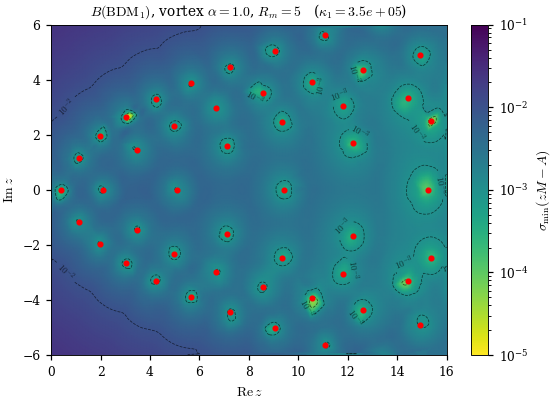

In [37]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.8, 3.9))
    r_ = ps_alpha[("B(BDM)", 1.0)]
    ps.plot_pseudospectrum(r_, ax=ax,
                           title=r"$B(\mathrm{BDM}_1)$, vortex $\alpha=1.0$, $R_m=5$"
                                 + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "bregT_ps_b9_BBDM_a100.pdf")
    plt.show()

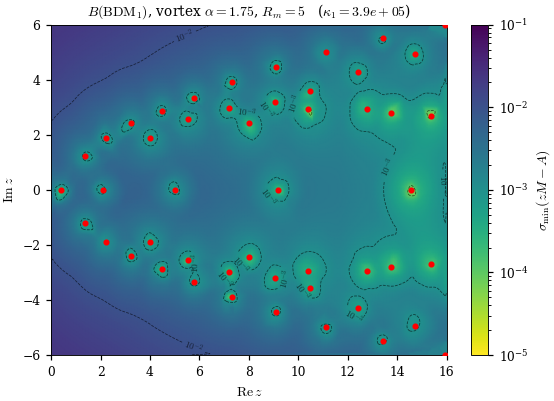

In [38]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.8, 3.9))
    r_ = ps_alpha[("B(BDM)", 1.75)]
    ps.plot_pseudospectrum(r_, ax=ax,
                           title=r"$B(\mathrm{BDM}_1)$, vortex $\alpha=1.75$, $R_m=5$"
                                 + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "bregT_ps_b9_BBDM_a175.pdf")
    plt.show()

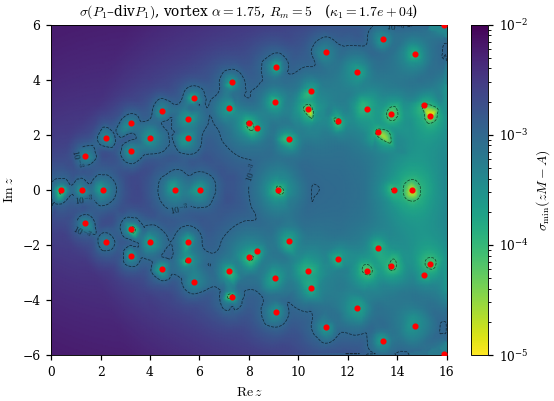

In [39]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.8, 3.9))
    r_ = ps_alpha[("s(P1-divP1)", 1.75)]
    ps.plot_pseudospectrum(r_, ax=ax,
                           title=r"$\sigma(P_1$–div$P_1)$, vortex $\alpha=1.75$, $R_m=5$"
                                 + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "bregT_ps_b9_sP1_a175.pdf")
    plt.show()

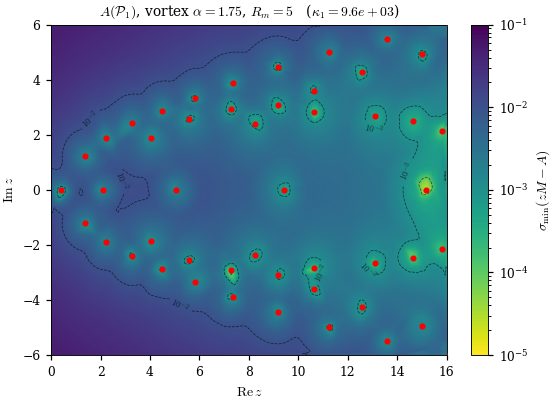

In [40]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.8, 3.9))
    r_ = ps_alpha[("A(CG)", 1.75)]
    ps.plot_pseudospectrum(r_, ax=ax,
                           title=r"$A(\mathcal{P}_1)$, vortex $\alpha=1.75$, $R_m=5$"
                                 + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "bregT_ps_b9_ACG_a175.pdf")
    plt.show()

<a id="5"></a>
## 5. Summary

**What the loss of regularity does.**

1. **$h$-convergence survives everything tested.** $O(h^{2r})$ on the first five
   eigenvalues, for every field from the discontinuous shears down to the $L^p$ vortex, in
   every discretisation — the deliberately spurious one included, whose genuine modes are as
   accurate as anybody's.
2. **$p$-convergence is the first casualty.** Exponential convergence goes as soon as
   $\beta$ leaves $W^{1,\infty}$, and is weakest for the point singularity. For rough data,
   refine $h$ before raising $r$.
3. **Cross-formulation agreement degrades measurably and monotonically**, with the
   roughness of the field and with $\alpha$. It is a usable proxy for regularity where no
   error estimate exists.
4. **The well-posedness shift $\nu$ remains spectrally inert** for $L^\infty$ fields, which
   the smooth case alone does not establish.

**What the loss of regularity does *not* do.**

1. **It does not create pollution.** No FEEC discretisation acquires a spurious eigenvalue
   for any field tested, however rough — the wide-window scans of Section 3.6 find the same
   spectrum in every space.
2. **It does not remove pollution either.** The shadow spectrum of
   $\sigma(P_1\text{–div}P_1)$ stays near $6$, $15$ and $24$ under every field and every
   $\alpha$ — moving by $12\%$ where the genuine spectrum moves by $45\%$, and by less than
   $0.1\%$ across the whole range of $\alpha$ — with an essentially unchanged count.
   Pollution is a property of the space pair, not of the data, which is the sharpest
   statement this notebook can make and needs the paired comparison to make it.
3. **It does not degrade the conditioning.** $\kappa_1(A-\tau M)$ is reported with every
   table and figure here; it is flat in $\alpha$ and in the roughness of $\beta$, and grows
   only with $h^{-1}$ and mildly with $R_m$, as it must.

**One thing that does change under advection.** The $3\varepsilon(m^2+n^2)$ rule of the
diffusive limit does not survive a wind: the *diffusive* part of a spurious eigenvalue is
tripled, the advective part is not. A complex spurious value carries an imaginary part
within a few per cent of the genuine mode it shadows — a ratio near $1$, not near $3$ — so
it is transported at very nearly the same rate as a real mode. That is exactly why
advection camouflages pollution rather than exposing it.

**Caveats.** Nothing is stabilised, deliberately. For the bounded fields that means
respecting $h\|\beta\|_\infty R_m/2 \lesssim 1$, which every table above does; for the
vortex there is no mesh-independent $\|\beta\|_\infty$, so the effective magnitude is
reported in Section 4.1 and the Reynolds numbers kept correspondingly modest.

In [41]:
klog = pd.DataFrame(KAPPA_LOG)
worst = klog.loc[klog[r"Hager $\kappa_1$"].idxmax()]
print(f"{len(klog)} eigensolves, each with kappa(A - tau M) estimated.\n")
print(f"  worst normwise kappa_1 : {worst[r'Hager $\kappa_1$']:.3e}"
      f"   ({worst.get('form', '?')}, field {worst.get('field', '?')}, "
      f"r={worst.get('r', 0):.0f}, Rm={worst.get('Rm', 1):g}, n={worst['n']:.0f})")
print(f"  median normwise kappa_1: {klog[r'Hager $\kappa_1$'].median():.3e}")
print(f"  worst MUMPS COND1      : {klog['MUMPS COND1'].max():.3e}")
print(f"  MUMPS INFOG(1) != 0    : {int((klog['INFOG(1)'] != 0).sum())} of {len(klog)}")
print(f"\nfigures written to {FIGDIR.resolve()}")
for q in sorted(FIGDIR.glob("bregT_*.pdf")):
    print("  ", q.name)

290 eigensolves, each with kappa(A - tau M) estimated.

  worst normwise kappa_1 : 1.292e+07   (B(BDM), field b9, r=3, Rm=5, n=46272)
  median normwise kappa_1: 1.107e+04
  worst MUMPS COND1      : 1.584e+05
  MUMPS INFOG(1) != 0    : 0 of 290

figures written to /Users/lourenco/Desktop/Dissertation_Firedrake/Experiments/final/figures
   bregT_h_b7_ACG.pdf
   bregT_h_b7_BBDM.pdf
   bregT_h_b7_BRT.pdf
   bregT_h_b7_sP1.pdf
   bregT_h_b9_ACG.pdf
   bregT_h_b9_BBDM.pdf
   bregT_h_b9_BRT.pdf
   bregT_h_b9_sP1.pdf
   bregT_p_b7_ACG.pdf
   bregT_p_b7_BBDM.pdf
   bregT_p_b7_BRT.pdf
   bregT_p_b9_ACG.pdf
   bregT_p_b9_BBDM.pdf
   bregT_p_b9_BRT.pdf
   bregT_ps_b9_ACG_a175.pdf
   bregT_ps_b9_BBDM_a100.pdf
   bregT_ps_b9_BBDM_a175.pdf
   bregT_ps_b9_sP1_a175.pdf
   bregT_ps_wide_b7_BBDM.pdf
   bregT_ps_wide_b7_sP1.pdf
